# 04 — Informe de negocio: Canary Islands Tourism Forecast

Aplicar `src/business.py` (`revpar_gap_vs_last_year`, `demand_alert_level`)
sobre el pronóstico del modelo ganador para cada isla, y exportar los
gráficos clave (pronóstico + intervalo, alerta de demanda por isla) a
`reports/figures/` para el README.

In [1]:
import json
import pickle
from pathlib import Path

import pandas as pd

from src.business import demand_alert_level, revpar_gap_vs_last_year
from src.data import load_harmonized_series
from src.model import forecast_recursive_lightgbm

HORIZON = 3

with open("models/registry.json") as f:
    registry = json.load(f)

df = load_harmonized_series()
rows = []

for isla, info in registry.items():
    grupo = df[df["isla"] == isla].sort_values("fecha").reset_index(drop=True)
    with open(info["path"], "rb") as f:
        fitted = pickle.load(f)

    if info["model_type"] == "sarima":
        forecast_revpar = fitted.forecast(steps=HORIZON)
        forecast_dates = pd.date_range(
            grupo["fecha"].max() + pd.DateOffset(months=1), periods=HORIZON, freq="MS"
        )
        forecast_revpar = pd.Series(forecast_revpar.values, index=forecast_dates)
    else:
        forecast_revpar = forecast_recursive_lightgbm(fitted, grupo, "revpar_eur", HORIZON)

    last_adr = grupo["adr_eur"].iloc[-1]  # se asume ADR constante al del último mes real disponible

    for fecha_pronostico, revpar_pred in forecast_revpar.items():
        mismo_mes_año_pasado = grupo[grupo["fecha"] == fecha_pronostico - pd.DateOffset(years=1)]
        if mismo_mes_año_pasado.empty:
            continue

        last_year_occupancy = mismo_mes_año_pasado["grado_ocupacion"].iloc[0]
        last_year_revpar = mismo_mes_año_pasado["revpar_eur"].iloc[0]
        forecast_occupancy = min(revpar_pred / last_adr, 1.0)

        opportunity = revpar_gap_vs_last_year(forecast_occupancy, last_year_occupancy, last_adr)
        yoy_growth = (revpar_pred - last_year_revpar) / last_year_revpar
        alerta = demand_alert_level(yoy_growth)

        rows.append(
            {
                "isla": isla,
                "modelo": info["model_type"],
                "fecha_pronostico": fecha_pronostico.date(),
                "revpar_pronosticado_eur": round(revpar_pred, 1),
                "revpar_año_pasado_eur": round(last_year_revpar, 1),
                "yoy_growth_pct": round(yoy_growth * 100, 1),
                "nivel_alerta": alerta,
                "gap_revpar_eur": round(opportunity.gap_eur, 1),
                "adr_aumento_necesario_pct": round(opportunity.adr_increase_needed_pct * 100, 1),
            }
        )

informe = pd.DataFrame(rows)
informe

.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


,isla,modelo,fecha_pronostico,revpar_pronosticado_eur,revpar_año_pasado_eur,yoy_growth_pct,nivel_alerta,gap_revpar_eur,adr_aumento_necesario_pct
0,El Hierro,sarima,2026-02-01,55.4,51.5,7.6,crecimiento,-2.1,-3.9
1,El Hierro,sarima,2026-03-01,56.2,55.8,0.8,estable,0.2,0.4
2,El Hierro,sarima,2026-04-01,52.6,55.4,-5.1,alerta_media,5.4,10.3
3,Fuerteventura,sarima,2026-02-01,104.4,101.7,2.7,estable,2.1,2.0
4,Fuerteventura,sarima,2026-03-01,111.7,106.9,4.5,estable,-3.2,-2.8
5,Fuerteventura,sarima,2026-04-01,96.5,91.5,5.5,crecimiento,-3.9,-4.1
6,Gran Canaria,sarima,2026-02-01,160.2,150.8,6.2,crecimiento,-7.7,-4.8
7,Gran Canaria,sarima,2026-03-01,153.4,142.5,7.7,crecimiento,-7.2,-4.7
8,Gran Canaria,sarima,2026-04-01,125.0,113.0,10.6,crecimiento,1.4,1.1
9,La Gomera,lightgbm,2026-02-01,125.0,122.7,1.9,estable,5.7,4.6


In [2]:
Path("reports").mkdir(exist_ok=True)
informe.to_csv("reports/informe_negocio.csv", index=False)

print("=== Resumen por isla (nivel de alerta más frecuente en el horizonte de 3 meses) ===")
resumen = informe.groupby("isla").agg(
    nivel_alerta_predominante=("nivel_alerta", lambda s: s.mode()[0]),
    yoy_growth_medio_pct=("yoy_growth_pct", "mean"),
    gap_revpar_medio_eur=("gap_revpar_eur", "mean"),
).round(1).sort_values("yoy_growth_medio_pct")
print(resumen)

=== Resumen por isla (nivel de alerta más frecuente en el horizonte de 3 meses) ===
              nivel_alerta_predominante  yoy_growth_medio_pct  \
isla                                                            
La Gomera                       estable                  -2.2   
El Hierro                  alerta_media                   1.1   
Lanzarote                       estable                   2.6   
Fuerteventura                   estable                   4.2   
Gran Canaria                crecimiento                   8.2   
La Palma                    crecimiento                  10.9   
Tenerife                    crecimiento                  11.5   

               gap_revpar_medio_eur  
isla                                 
La Gomera                      10.9  
El Hierro                       1.2  
Lanzarote                      -4.5  
Fuerteventura                  -1.7  
Gran Canaria                   -4.5  
La Palma                       -0.9  
Tenerife                  

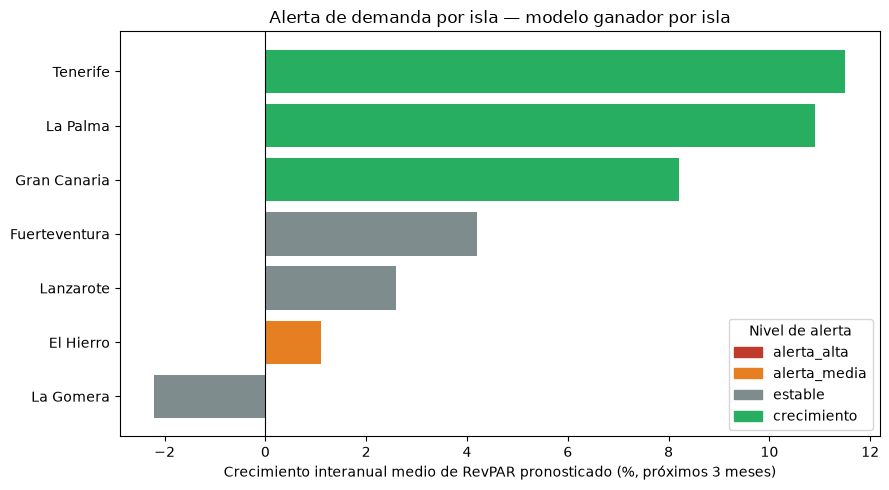

In [3]:
import matplotlib.pyplot as plt

color_por_alerta = {
    "alerta_alta": "#c0392b",
    "alerta_media": "#e67e22",
    "estable": "#7f8c8d",
    "crecimiento": "#27ae60",
}

fig, ax = plt.subplots(figsize=(9, 5))
colores = resumen["nivel_alerta_predominante"].map(color_por_alerta)
ax.barh(resumen.index, resumen["yoy_growth_medio_pct"], color=colores)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Crecimiento interanual medio de RevPAR pronosticado (%, próximos 3 meses)")
ax.set_title("Alerta de demanda por isla — modelo ganador por isla")

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in color_por_alerta.values()]
ax.legend(handles, color_por_alerta.keys(), title="Nivel de alerta", loc="lower right")

plt.tight_layout()
Path("reports/figures").mkdir(parents=True, exist_ok=True)
plt.savefig("reports/figures/04_alerta_demanda_por_isla.png", dpi=110, bbox_inches="tight")
plt.show()